# Construcción del Dataset de Benchmark

Se construyó un subconjunto a partir de los ratings crudos de MovieLens 32M para permitir una comparación justa contra el benchmark ML-1M.

**Objetivo**: ~6k usuarios, ~3.9k películas, ~1M ratings, ~4.3% de densidad.

Las dimensiones se ajustaron para aproximarse a las del dataset de referencia MovieLens 1M (1,000,209 ratings, 6,040 usuarios, 3,882 ítems, 4.27% de densidad).

**Pipeline**:
1. Se **cargaron** los ratings crudos de 32M y se **restringieron** a las 5k películas del catálogo con el que hemos estado trabajando
2. Se **aplicó filtrado** k-core (≥20 ratings por usuario Y por ítem) de forma iterativa
3. Se **seleccionaron** 6,000 usuarios con entre 70 y 500 ratings cada uno (activos pero no superusuarios)
4. Se **conservaron** las ~4,000 películas con mayor cantidad de ratings
5. Se **re-aplicó filtrado** k-core (≥3 ratings por usuario Y por ítem) de forma iterativa para tener datos de calidad
6. Se **re-indexaro**n user_id y movie_id a enteros consecutivos base 0
7. Se **guardaron** todos los artefactos

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from ml.config import (
    DATA_DIR, ML_RAW_RATINGS, ML_MOVIES,
    RATINGS_PATH, MOVIES_PATH,
)

## 1. Carga de ratings crudos y restricción al catálogo

In [4]:
movies_full = pd.read_csv(ML_MOVIES)
valid_ml_ids = set(movies_full['movielens_id'].values)
print(f'Catálogo: {len(movies_full)} películas')

raw = pd.read_parquet(ML_RAW_RATINGS)
print(f'Crudos: {len(raw):,} ratings, {raw["userId"].nunique():,} usuarios, {raw["movieId"].nunique():,} ítems')

df = raw[raw['movieId'].isin(valid_ml_ids)].copy()
print(f'Tras filtro de catálogo: {len(df):,} ratings, {df["userId"].nunique():,} usuarios, {df["movieId"].nunique():,} ítems')

Catálogo: 5000 películas
Crudos: 32,000,204 ratings, 200,948 usuarios, 84,432 ítems
Tras filtro de catálogo: 15,345,216 ratings, 200,662 usuarios, 4,998 ítems


## 2. Filtrado k-core (≥20 por usuario Y por ítem)

Técnica estándar en investigación de sistemas de recomendación. Se **eliminaron** usuarios e ítems con muy pocas interacciones. Se aplicó de forma iterativa porque eliminar usuarios puede hacer que ciertos ítems caigan por debajo del umbral y viceversa.

**Ejemplo**: supóngase que el umbral es 20. Si el usuario A solo calificó 5 películas, se elimina. Pero una de esas 5 películas (película X) tenía exactamente 20 ratings — al quitar al usuario A, la película X queda con 19 ratings y ahora también debe eliminarse. A su vez, otro usuario B que calificó la película X pierde una interacción y podría caer por debajo del umbral. Por eso el proceso se repitió hasta que ningún usuario ni ítem quedara por debajo del mínimo (convergencia).

In [5]:
MIN_RATINGS = 20

for iteration in range(50):
    n_before = len(df)
    uc = df.groupby('userId').size()
    df = df[df['userId'].isin(uc[uc >= MIN_RATINGS].index)]
    ic = df.groupby('movieId').size()
    df = df[df['movieId'].isin(ic[ic >= MIN_RATINGS].index)]
    if len(df) == n_before:
        print(f'Filtro k-core (20) convergió tras {iteration + 1} iteraciones')
        break

print(f'Tras k-core ({MIN_RATINGS}): {len(df):,} ratings, {df["userId"].nunique():,} usuarios, {df["movieId"].nunique():,} ítems')

Filtro k-core (20) convergió tras 3 iteraciones
Tras k-core (20): 14,601,254 ratings, 135,121 usuarios, 4,442 ítems


## 3. Selección de usuarios con actividad moderada

Se **seleccionaron** usuarios con entre 70 y 500 ratings. Esto también preservó la distribución natural de popularidad (las películas populares fueron calificadas por muchos de ellos).

Se **tomaron** 6,000 usuarios aleatorios (con semilla fija) de este pool. El rango 70–500 se eligió para que el total de ratings se aproxime a ~1M, igualando la escala de MovieLens-1M.

**Nota**: algunos usuarios pueden quedar por debajo de 70 ratings en el dataset final porque el paso 4 (selección de top-4,000 ítems) elimina películas poco calificadas, lo que reduce el conteo de ratings de ciertos usuarios.

In [6]:
TARGET_USERS = 6000
MIN_ACTIVITY = 70
MAX_ACTIVITY = 500
rng = np.random.default_rng(42)

uc = df.groupby('userId').size()
eligible_users = uc[(uc >= MIN_ACTIVITY) & (uc <= MAX_ACTIVITY)].index
print(f'Usuarios con {MIN_ACTIVITY}-{MAX_ACTIVITY} ratings: {len(eligible_users):,}')

if len(eligible_users) > TARGET_USERS:
    selected_users = rng.choice(eligible_users, size=TARGET_USERS, replace=False)
else:
    selected_users = eligible_users

df = df[df['userId'].isin(selected_users)].copy()
print(f'Tras selección de usuarios: {len(df):,} ratings, {df["userId"].nunique():,} usuarios, {df["movieId"].nunique():,} ítems')

Usuarios con 70-500 ratings: 56,426
Tras selección de usuarios: 1,000,942 ratings, 6,000 usuarios, 4,294 ítems


## 4. Conservación de las ~4,000 películas con más ratings

Se enfocó el catálogo en las películas que cuentan con suficiente señal para aprender embeddings. Posteriormente se re-aplicó el filtrado k-core para limpiar usuarios que pudieran haber caído por debajo del umbral.

In [7]:
TARGET_ITEMS = 4000

item_counts = df.groupby('movieId').size().sort_values(ascending=False)
top_items = item_counts.head(TARGET_ITEMS).index
df = df[df['movieId'].isin(top_items)].copy()
print(f'Tras top-{TARGET_ITEMS} ítems: {len(df):,} ratings, {df["userId"].nunique():,} usuarios, {df["movieId"].nunique():,} ítems')

# Re-aplicar k-core tras selección de ítems
for iteration in range(50):
    n_before = len(df)
    uc = df.groupby('userId').size()
    df = df[df['userId'].isin(uc[uc >= 3].index)]
    ic = df.groupby('movieId').size()
    df = df[df['movieId'].isin(ic[ic >= 3].index)]
    if len(df) == n_before:
        print(f'Filtro k-core (3): convergió tras {iteration + 1} iteraciones')
        break

n_users = df['userId'].nunique()
n_items = df['movieId'].nunique()
density = len(df) / (n_users * n_items) * 100
print(f'Final: {len(df):,} ratings, {n_users:,} usuarios, {n_items:,} ítems, densidad={density:.2f}%')

Tras top-4000 ítems: 1,000,619 ratings, 6,000 usuarios, 4,000 ítems
Filtro k-core (3): convergió tras 2 iteraciones
Final: 1,000,279 ratings, 6,000 usuarios, 3,830 ítems, densidad=4.35%


## 5. Re-indexación y construcción de artefactos

**Crítico**: el movie_id debió ser re-indexado de 0 a N-1 de forma consistente entre los ratings y el CSV de películas. Se preservaron las columnas originales `movielens_id` y `tmdb_id` para trazabilidad.

In [8]:
surviving_ml_ids = sorted(df['movieId'].unique())
ml_id_to_new = {ml_id: new_idx for new_idx, ml_id in enumerate(surviving_ml_ids)}
print(f'Re-indexación de películas: {len(ml_id_to_new)} películas → 0..{len(ml_id_to_new)-1}')

surviving_users = sorted(df['userId'].unique())
user_to_new = {uid: new_idx for new_idx, uid in enumerate(surviving_users)}
print(f'Re-indexación de usuarios: {len(user_to_new)} usuarios → 0..{len(user_to_new)-1}')

ratings_bench = df.copy()
ratings_bench['user_id'] = ratings_bench['userId'].map(user_to_new)
ratings_bench['movie_id'] = ratings_bench['movieId'].map(ml_id_to_new)
ratings_bench = ratings_bench[['user_id', 'movie_id', 'rating', 'timestamp']].reset_index(drop=True)
print(f'Forma del DataFrame de ratings: {ratings_bench.shape}')

Re-indexación de películas: 3830 películas → 0..3829
Re-indexación de usuarios: 6000 usuarios → 0..5999
Forma del DataFrame de ratings: (1000279, 4)


In [9]:
# Películas — se heredaron todos los metadatos incluyendo el score original de TMDb.
# Se preservaron las columnas `score`, `vote_count`, `vote_average` del catálogo TMDb
# para que Popularity rankee con los mismos criterios que en ml/.
movies_bench = movies_full[movies_full['movielens_id'].isin(surviving_ml_ids)].copy()
movies_bench['movie_id'] = movies_bench['movielens_id'].map(ml_id_to_new)
movies_bench = movies_bench.sort_values('movie_id').reset_index(drop=True)
print(f'Forma del DataFrame de películas: {movies_bench.shape}')

Forma del DataFrame de películas: (3830, 17)


## 6. Guardado de artefactos

In [10]:
ratings_bench.to_parquet(RATINGS_PATH, index=False)
movies_bench.to_csv(MOVIES_PATH, index=False)

print('Artefactos guardados:')
print(f'   ratings_benchmark.parquet ({RATINGS_PATH.stat().st_size / 1e6:.1f} MB)')
print(f'   movies_benchmark.csv ({MOVIES_PATH.stat().st_size / 1e6:.1f} MB)')
print()
print('Nota: cosine_sim_benchmark.npy se genera por separado con:')
print('   python -m ml.scripts.build_content_similarity')

Artefactos guardados:
   ratings_benchmark.parquet (6.6 MB)
   movies_benchmark.csv (2.8 MB)

Nota: cosine_sim_benchmark.npy se genera por separado con:
   python -m ml.scripts.build_content_similarity


## 6.1 Versión en español del catálogo benchmark

Se genera `movies_benchmark_spanish.csv` a partir de `movies_final_spanish.csv`, conservando únicamente las 3,830 películas del benchmark y re-asignando el `movie_id` consistente con `movies_benchmark.csv`.

In [11]:
SPANISH_CSV = DATA_DIR.parent / 'processed' / 'movies_final_spanish.csv'
SPANISH_BENCH_PATH = DATA_DIR / 'movies_benchmark_spanish.csv'

spanish_full = pd.read_csv(SPANISH_CSV)
spanish_bench = spanish_full[spanish_full['movielens_id'].isin(surviving_ml_ids)].copy()
spanish_bench = spanish_bench.drop(columns=['movie_id'], errors='ignore')
spanish_bench['movie_id'] = spanish_bench['movielens_id'].map(ml_id_to_new)
spanish_bench = spanish_bench.sort_values('movie_id').reset_index(drop=True)

spanish_bench.to_csv(SPANISH_BENCH_PATH, index=False)
print(f'movies_benchmark_spanish.csv: {spanish_bench.shape[0]} películas ({SPANISH_BENCH_PATH.stat().st_size / 1e6:.1f} MB)')

movies_benchmark_spanish.csv: 3830 películas (3.2 MB)


## 6.2 Derivación de personalidades Big Five

Se derivan los rasgos de personalidad para los 6,000 usuarios del benchmark usando la metodología de Nave et al. (2020): se calculan pesos softmax por género a partir de sus ratings promedio y se proyectan contra la matriz de loadings Big Five × género.

In [12]:
from ml.config import derive_personalities

PERSONALITY_PATH = DATA_DIR / 'personality_benchmark.csv'

personality_bench = derive_personalities(ratings_bench, movies_bench)
personality_bench.to_csv(PERSONALITY_PATH, index=False)
print(f'personality_benchmark.csv: {len(personality_bench)} usuarios ({PERSONALITY_PATH.stat().st_size / 1e6:.1f} MB)')

personality_benchmark.csv: 6000 usuarios (0.6 MB)


## 7. Estadísticas finales

In [13]:
print('=' * 50)
print('RESUMEN DEL DATASET DE BENCHMARK')
print('=' * 50)
n_users = ratings_bench['user_id'].nunique()
n_items = ratings_bench['movie_id'].nunique()
n_ratings = len(ratings_bench)
density = n_ratings / (n_users * n_items) * 100

print(f'Usuarios:  {n_users:,}')
print(f'Ítems:     {n_items:,}')
print(f'Ratings:   {n_ratings:,}')
print(f'Densidad:  {density:.2f}%')
print()

uc = ratings_bench.groupby('user_id').size()
ic = ratings_bench.groupby('movie_id').size()
print(f'Ratings/usuario: media={uc.mean():.0f}, mediana={uc.median():.0f}, mín={uc.min()}, máx={uc.max()}')
print(f'Ratings/ítem:    media={ic.mean():.0f}, mediana={ic.median():.0f}, mín={ic.min()}, máx={ic.max()}')
print()

print()
print('Comparación:')
print(f'  ML-1M referencia:  1,000,209 ratings,  6,040 usuarios,  3,882 ítems,  4.27% densidad')
print(f'  Este dataset:    {n_ratings:>10,} ratings,  {n_users:>5,} usuarios,  {n_items:>5,} ítems,  {density:.2f}% densidad')

RESUMEN DEL DATASET DE BENCHMARK
Usuarios:  6,000
Ítems:     3,830
Ratings:   1,000,279
Densidad:  4.35%

Ratings/usuario: media=167, mediana=132, mín=69, máx=500
Ratings/ítem:    media=261, mediana=51, mín=3, máx=4882


Comparación:
  ML-1M referencia:  1,000,209 ratings,  6,040 usuarios,  3,882 ítems,  4.27% densidad
  Este dataset:     1,000,279 ratings,  6,000 usuarios,  3,830 ítems,  4.35% densidad


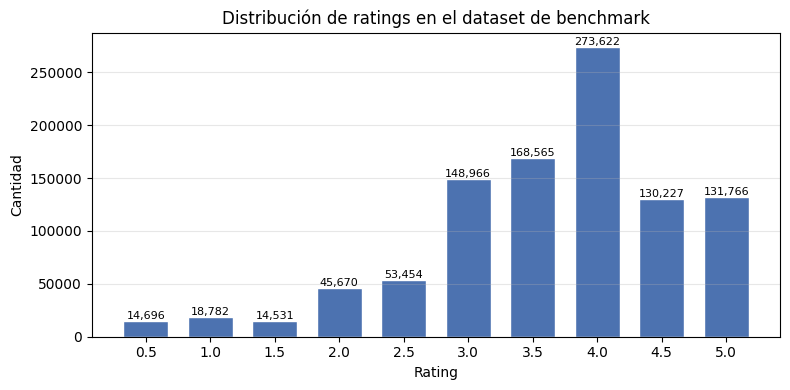

In [14]:
# Gráfica de distribución de ratings
import matplotlib.pyplot as plt

dist = ratings_bench['rating'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dist.index.astype(str), dist.values, color='#4C72B0', edgecolor='white', width=0.7)
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:,}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Rating')
ax.set_ylabel('Cantidad')
ax.set_title('Distribución de ratings en el dataset de benchmark')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()